In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr
import h5py
import os
from plotting_fxns import *
import pickle

with open('site_data.pkl','rb') as f:
    data_dict = pickle.load(f)

site_dict = {
    'wolverine':['EC'],
    'kahiltna':['KPS','KQU',],
    'gulkana':['T','Z'],
}

In [8]:
data_dict['EC'].keys()

print(data_dict['EC']['density_meas'][data_dict['EC']['dates'] == dates_wolverine[-1]])

[429.60662526 377.84679089 336.4389234  336.4389234  341.61490683
 346.79089027 428.06074142 489.58982734 403.87371361 454.89581137
 420.4346243  428.46267639 445.77100097 466.74133698 461.47393342
 474.53903959 476.79535634 480.5188894  471.71534494 482.86026792
 482.32196216 503.5569335  505.09827704 508.0011407  520.14038874
 515.45443929 522.03608703 534.39081035 533.81309055 532.64586076
 542.61220743 544.65594456 535.07592677 560.80322971 564.31669573
 580.57273223 547.00837115 526.99416294 494.11787971 572.75733007
 595.08705054 585.85066616 621.61321847 636.81571566 608.20799428
 610.97280049 622.0422131  661.85291474 906.23774922 601.14642614
 621.36973504 601.82584118 575.90290808 605.0436016  602.9024527
 625.51129468 633.71746695 698.27065885 673.02262926 660.01952717
 656.67483362 643.39590102 860.86563328 647.4648079  634.48305737
 644.59851018 647.79326183 658.36947835 648.79002827 657.64876737
 678.65537264 806.49125195 658.36947835 671.80559015 716.8657212
 699.2486289

EC ('1.75', '-9') 5.8417098617242385


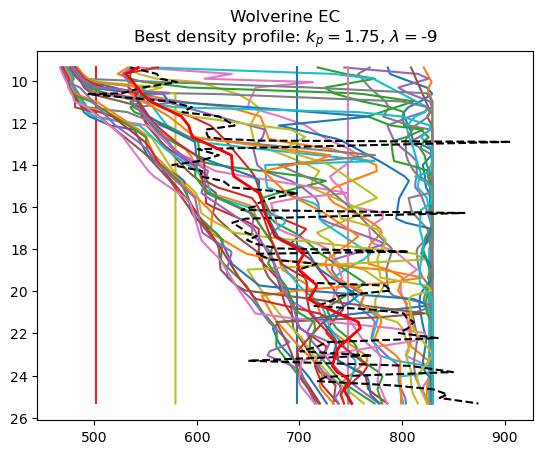

KPS ('1.75', '-5.5') 7.744391562969115


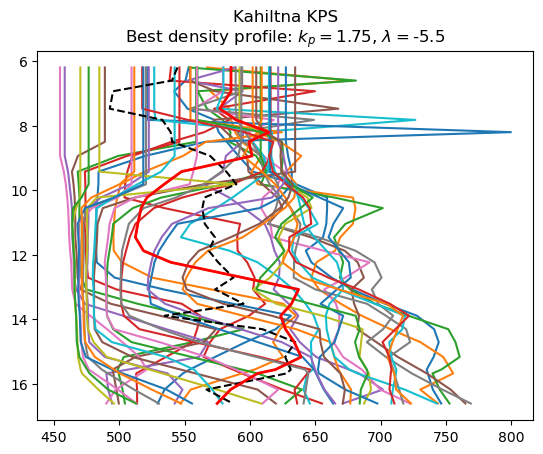

/trace/home/cvwilson/miniconda3/envs/cfm_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/trace/home/cvwilson/miniconda3/envs/cfm_env/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/trace/home/cvwilson/miniconda3/envs/cfm_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/trace/home/cvwilson/miniconda3/envs/cfm_env/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/trace/home/cvwilson/miniconda3/envs/cfm_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/trace/home/cvwil

KQU ('1.75', '-5.5') inf


/trace/home/cvwilson/miniconda3/envs/cfm_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/trace/home/cvwilson/miniconda3/envs/cfm_env/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


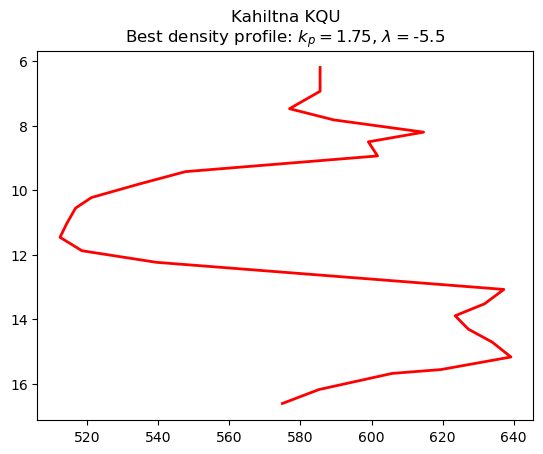

T ('3.5', '-3.5') 3.791723904693905


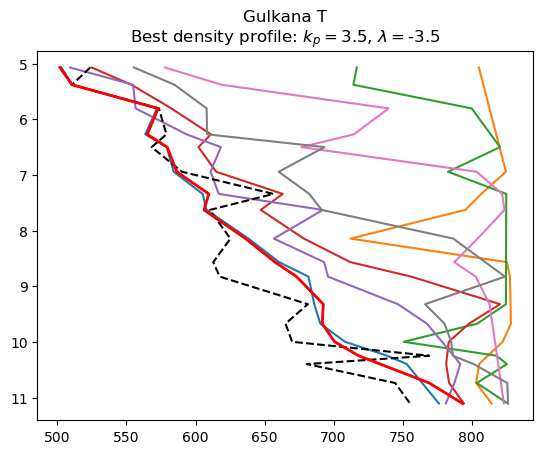

Z ('3.5', '-3.5') 5.904389480101673


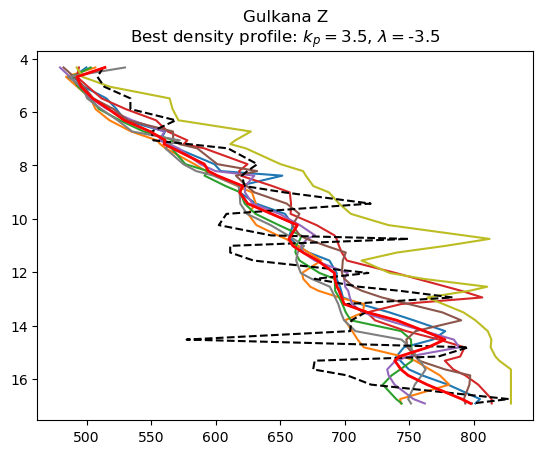

In [23]:

out_fp = '/trace/group/rounce/cvwilson/Firn/Output/'
for glacier in site_dict:
    for site in site_dict[glacier]:
        if site == 'EC':
            date = dates_wolverine[-1]
        elif site == 'KPS':
            date = dates_KPS[-1]
        elif site == 'KQU':
            date = dates_KQU[-1] 
        else:
            date = '2025_04_20'
            
        snow_df = pd.read_csv(f'../Data/cores/{glacier}/{glacier}{site}_snowdepth.csv')
        min_depth = snow_df.loc[snow_df['date'] == date, 'snowdepth'].values

        best_mape = np.inf

        fig, ax = plt.subplots() 
        for folder in os.listdir(out_fp + glacier + site):
            if 'kp' in folder:
                kp = folder.split('kp')[-1].split('_')[0]
                lapserate = folder.split('lr')[-1].split('_')[0]
                cfm_fn = f'{glacier}{site}/{folder}/CFMresults.hdf5'

                # load model data
                modeled = get_var_modeled(out_fp + cfm_fn, date, 'density')
                age, _ = get_var_modeled(out_fp + cfm_fn, date, 'age')
                condition = (age >= 1) & (modeled[0] <= 830)
                density_mod = modeled[0][condition]
                depth_mod = modeled[1][condition]

                # load measured data 
                density_meas = data_dict[site]['density_meas'][data_dict[site]['dates'] == date]
                layer_tops = data_dict[site]['layer_tops'][data_dict[site]['dates'] == date]
                layer_bottoms = data_dict[site]['layer_bottoms'][data_dict[site]['dates'] == date]
                layer_midpoints = ((layer_bottoms - layer_tops) / 2 + layer_bottoms)

                mask = layer_midpoints >= min_depth

                mod_interp = np.interp(layer_midpoints, depth_mod, density_mod)

                meas = density_meas[mask]
                mod = mod_interp[mask]
                depth = layer_midpoints[mask]

                mape = np.mean(np.abs((meas - mod) / meas)) * 100
                if mape < best_mape:
                    best_mape = mape 
                    best_params = (kp, lapserate)
                    best_data = {'depth': depth, 'density_mod': mod, 'density_meas': meas}

                ax.plot(mod, depth, label=f'$k_p=${kp}, $\lambda=${lapserate}')

        print(site, best_params, best_mape)
        ax.plot(meas, depth, 'k--')
        ax.plot(best_data['density_mod'], best_data['depth'], label='Best model', c='red', linewidth=2)
        
        # ax.legend()
        ax.invert_yaxis()
        ax.set_title(f'{glacier.capitalize()} {site}\nBest density profile: $k_p=${best_params[0]}, $\lambda=${best_params[1]}')
        plt.show()